# Data Analyst Skill Strategy: Reach, Pay Signal, and Evidence Quality

## Decision Question

Which skills offer Data Analysts the strongest trade-off between market reach,
compensation signal, and evidence quality — and how should that trade-off be
navigated without collapsing three independent dimensions into an arbitrary score?

Each preceding notebook addressed a different aspect of India's data-job market.
This notebook focuses specifically on the Data Analyst role and synthesises the
demand and compensation evidence into an actionable skill-strategy framework.

Three properties are evaluated for each skill:

1. **Market reach** — the share of Data Analyst postings that mention the skill.
   A skill with higher reach signals that more employers consider it relevant.
2. **Pay signal** — the median annual salary disclosed in Data Analyst postings
   that mention the skill. Higher pay signal suggests the skill is associated
   with better-compensated roles in the disclosed subset.
3. **Evidence quality** — the number of salary records available for a skill.
   A skill may have a high pay signal but very few observations; evidence quality
   determines how much weight the pay signal deserves.

Rather than collapsing these three properties into a score, the analysis uses a
**Pareto frontier** to identify skills that are not dominated by any alternative
on both reach and pay signal simultaneously. Skills on the frontier represent
the efficient boundary of the available trade-off space.


## Data Preparation

The analysis uses the 2023 Data Jobs dataset and restricts observations to
India-based Data Analyst postings. Skill fields are parsed from string-encoded
lists. Salary analyses are restricted to postings with disclosed annual salaries.

In [1]:
import ast
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

from datasets import load_dataset
from matplotlib.ticker import PercentFormatter, FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


In [2]:
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])


def parse_skills(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    if isinstance(value, list):
        return value
    return []


df["job_skills"] = df["job_skills"].apply(parse_skills)

india_jobs = df[df["job_country"] == "India"].copy()
analyst_jobs = india_jobs[india_jobs["job_title_short"] == "Data Analyst"].copy()

print(f"Total dataset postings: {len(df):,}")
print(f"India postings: {len(india_jobs):,}")
print(f"Analysis year: {india_jobs['job_posted_date'].dt.year.mode()[0]}")
print()
print(f"Data Analyst postings: {len(analyst_jobs):,}")
print(f"Data Analyst share of India postings: {len(analyst_jobs)/len(india_jobs):.1%}")
print(f"Data Analyst postings with salary: {analyst_jobs['salary_year_avg'].notna().sum():,}")
print(f"Salary coverage (DA): {analyst_jobs['salary_year_avg'].notna().mean():.2%}")

assert not india_jobs.empty
assert india_jobs["job_country"].eq("India").all()
assert india_jobs["job_posted_date"].dt.year.nunique() == 1

assert not analyst_jobs.empty
assert analyst_jobs["job_title_short"].eq("Data Analyst").all()
assert analyst_jobs["job_country"].eq("India").all()


Total dataset postings: 785,741
India postings: 51,088
Analysis year: 2023

Data Analyst postings: 6,121
Data Analyst share of India postings: 12.0%
Data Analyst postings with salary: 94
Salary coverage (DA): 1.54%


In [3]:
# Notebook-wide visualization settings

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "figure.titlesize": 16,
    "figure.dpi": 110,
})

os.makedirs("figures", exist_ok=True)


## Skill Metrics for Data Analyst Postings

For each skill that appears in at least 3% of Data Analyst postings, three
metrics are computed:

- **Prevalence**: share of all Data Analyst postings mentioning the skill.
- **Median salary**: median annual salary (USD) in the disclosed subset of
  Data Analyst postings that mention the skill.
- **Salary records**: count of disclosed-salary postings for the skill,
  used as a proxy for evidence quality.

Skills with fewer than five salary records are retained in the prevalence
analysis but excluded from Pay signal because the signal is too
sparse to interpret reliably.


In [4]:
# ------------------------------------------------------------------
# Compute per-skill: prevalence, median salary, and salary records
# ------------------------------------------------------------------

MIN_PREVALENCE = 0.03   # 3% floor — focuses on established skills
MIN_SALARY_N   = 5      # minimum salary records for pay-signal inclusion

analyst_skill_rows = analyst_jobs.explode("job_skills").dropna(subset=["job_skills"])

n_analyst = len(analyst_jobs)

# Posting-level prevalence
prevalence = (
    analyst_skill_rows
    .groupby("job_skills")
    .size()
    .div(n_analyst)
    .rename("prevalence")
)

# Salary metrics (disclosed subset only)
salary_stats = (
    analyst_skill_rows
    .dropna(subset=["salary_year_avg"])
    .groupby("job_skills")["salary_year_avg"]
    .agg(
        median_salary="median",
        salary_records="count",
    )
)

skill_profile = (
    prevalence[prevalence >= MIN_PREVALENCE]
    .to_frame()
    .join(salary_stats, how="left")
)

# Evidence quality flag
skill_profile["pay_signal_valid"] = (
    skill_profile["salary_records"] >= MIN_SALARY_N
)

assert skill_profile["prevalence"].between(0, 1).all()
assert (skill_profile["salary_records"].dropna() >= 0).all()

print(f"Skills above {MIN_PREVALENCE:.0%} prevalence: {len(skill_profile)}")
print(
    f"Skills with reliable pay signal ≥{MIN_SALARY_N} salary records: "
    f"{skill_profile['pay_signal_valid'].sum()}"
)
print()

display_table = (
    skill_profile
    .sort_values("prevalence", ascending=False)
    .reset_index()
    .rename(columns={
        "job_skills":     "Skill",
        "prevalence":     "Prevalence",
        "median_salary":  "Median Salary (USD)",
        "salary_records": "Salary Records",
    })
    .assign(**{
        "Salary Records": lambda df: df["Salary Records"].fillna(0).astype(int),
    })
)

display_table.insert(0, "Rank", range(1, len(display_table) + 1))

display(
    display_table.drop(columns=["pay_signal_valid"])
    .style
    .format({
        "Prevalence":          "{:.1%}",
        "Median Salary (USD)": lambda v: f"${v:,.0f}" if pd.notna(v) else "—",
        "Salary Records":      "{:,}",
    })
    .hide(axis="index")
)


Skills above 3% prevalence: 25
Skills with reliable pay signal ≥5 salary records: 16



Rank,Skill,Prevalence,Median Salary (USD),Salary Records
1,sql,51.6%,"$96,050",46
2,python,36.0%,"$96,050",36
3,excel,34.6%,"$98,500",39
4,tableau,27.2%,"$108,088",20
5,power bi,21.0%,"$111,175",17
6,r,16.2%,"$79,200",18
7,sas,15.6%,"$79,200",2
8,azure,8.4%,"$93,600",15
9,aws,7.4%,"$79,200",12
10,powerpoint,6.1%,"$111,175",10


## Market Reach: Skills by Data Analyst Prevalence

This chart answers the question: which skills are most commonly required by employers
advertising Data Analyst roles in India?

Prevalence determines how broadly accessible a skill is across the market.
A skill with 50% prevalence appears in half of all Data Analyst postings;
a skill with 5% prevalence is associated with a narrower subset of opportunities.


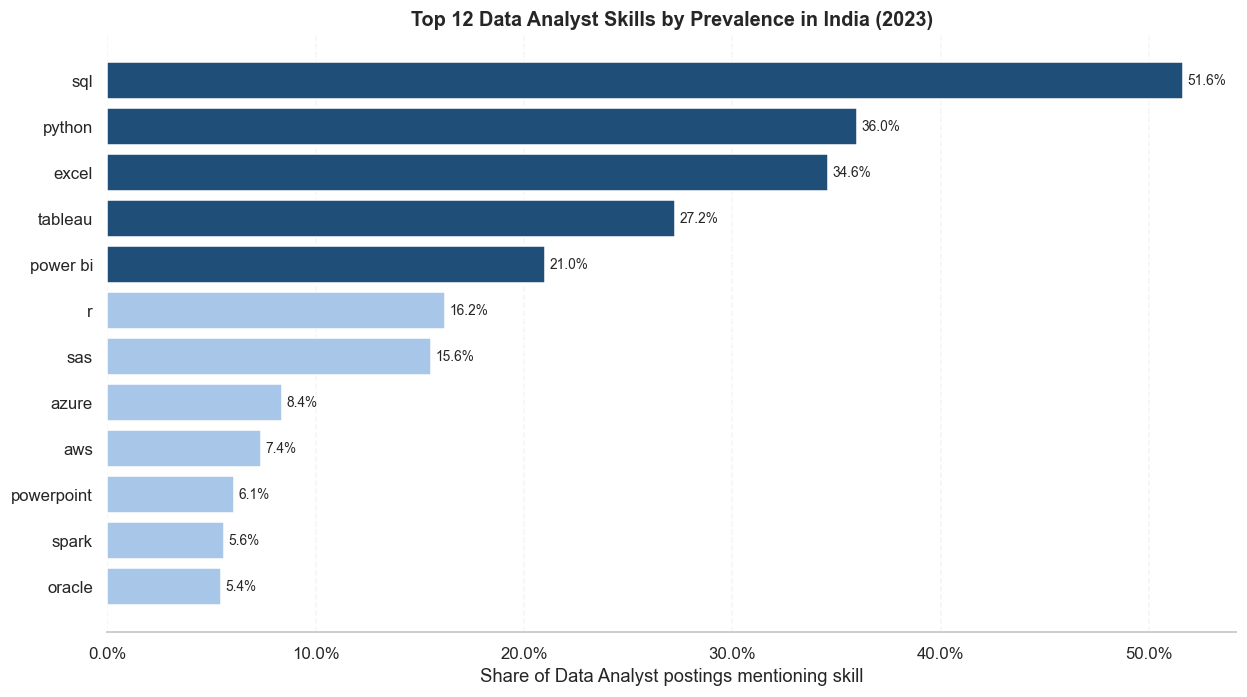

Rank,Skill,Prevalence
1,sql,51.6%
2,python,36.0%
3,excel,34.6%
4,tableau,27.2%
5,power bi,21.0%
6,r,16.2%
7,sas,15.6%
8,azure,8.4%
9,aws,7.4%
10,powerpoint,6.1%


In [5]:
# ------------------------------------------------------------------
# Bar chart — Top 12 skills by prevalence for Data Analyst postings
# ------------------------------------------------------------------

TOP_N = 12

plot_data = (
    skill_profile
    .sort_values("prevalence", ascending=False)
    .head(TOP_N)
    .sort_values("prevalence")
    .copy()
)

# Highlight top 5 by prevalence
top5_skills = (
    plot_data["prevalence"]
    .nlargest(5)
    .index
    .tolist()
)

plot_data["color"] = plot_data.index.map(
    lambda s: "#1f4e79" if s in top5_skills else "#a8c7e8"
)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

bars = ax.barh(
    plot_data.index,
    plot_data["prevalence"],
    color=plot_data["color"],
)

ax.bar_label(
    bars,
    labels=[f"{v:.1%}" for v in plot_data["prevalence"]],
    padding=3,
    fontsize=9,
)

ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=1))
ax.set_xlim(0, plot_data["prevalence"].max() * 1.05)

ax.set(
    title="Top 12 Data Analyst Skills by Prevalence in India (2023)",
    xlabel="Share of Data Analyst postings mentioning skill",
    ylabel="",
)

ax.grid(axis="x", linestyle="--", alpha=0.20)
ax.grid(axis="y", visible=False)
sns.despine(left=True, top=True, right=True)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    "figures/05_analyst_skill_reach.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print()

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------

summary_table = (
    plot_data.sort_values("prevalence", ascending=False)
    .reset_index()
    .rename(
        columns={
            "job_skills": "Skill",
            "prevalence": "Prevalence",
        }
    )
)

summary_table.insert(0, "Rank", range(1, len(summary_table) + 1))

display(
    summary_table[["Rank", "Skill", "Prevalence"]]
    .style
    .format({"Prevalence": "{:.1%}"})
    .hide(axis="index")
)

SQL and Python lead Data Analyst demand, each appearing in more than half of postings.
Excel retains a strong presence, reflecting the role's ongoing emphasis on spreadsheet
literacy and reporting. Tableau, Power BI, and R follow as the primary specialisation
tools, while cloud platforms (AWS, Azure) and databases (Spark, Oracle) represent smaller but still meaningful segments of employer demand.

The distribution is right-skewed: a small number of skills have very high reach, while
most established skills cluster in the 5–20% range. This pattern means that foundational skills therefore maximize market reach, while specialised tools expand capability within narrower segments of the market.


## Pareto Frontier: Reach vs Pay Signal

Market reach and pay signal are the two primary axes along which skill strategy can be
evaluated. A skill that has both higher reach and higher median salary than another
skill is said to **dominate** the other. Skills that are not dominated by any other
skill on both dimensions lie on the **Pareto frontier** — they represent the efficient
boundary of the available trade-off space.

This analysis uses only skills with at least five disclosed salary records to ensure
the pay signal is not driven by a single extreme observation.

Bubble area represents evidence quality (number of salary records). A large bubble
indicates the pay signal rests on stronger ground; a small bubble warrants caution.


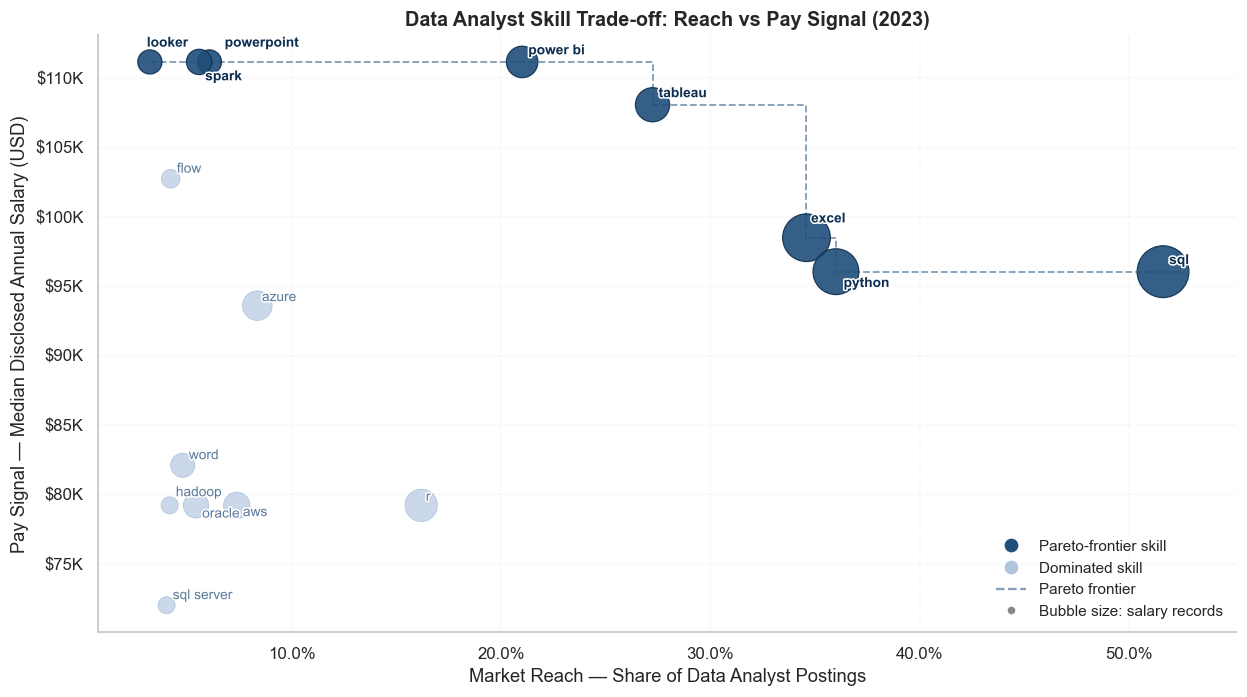

Rank,Skill,Prevalence,Median Salary (USD),Salary Records
1,sql,51.6%,"$96,050",46
2,python,36.0%,"$96,050",36
3,excel,34.6%,"$98,500",39
4,tableau,27.2%,"$108,088",20
5,power bi,21.0%,"$111,175",17
6,powerpoint,6.1%,"$111,175",10
7,spark,5.6%,"$111,175",11
8,looker,3.2%,"$111,175",10


In [6]:
# ------------------------------------------------------------------
# Pareto frontier analysis
# ------------------------------------------------------------------

# Restrict to skills with valid pay signal
pareto_data = (
    skill_profile[skill_profile["pay_signal_valid"]]
    .copy()
)

assert len(pareto_data) >= 3, "Too few skills with valid pay signal"

# Identify Pareto-dominant skills on (prevalence, median_salary)
def is_pareto_dominant(df, skill):
    """
    Returns True if no other skill in df has
    BOTH higher prevalence AND higher median_salary than skill.
    """
    row = df.loc[skill]
    dominated = (
        (df["prevalence"]    > row["prevalence"]) &
        (df["median_salary"] > row["median_salary"])
    )
    return not dominated.any()

pareto_data["on_frontier"] = [
    is_pareto_dominant(pareto_data, s) for s in pareto_data.index
]

frontier = pareto_data[pareto_data["on_frontier"]].sort_values("prevalence")

# ------------------------------------------------------------------
# Scatter plot with Pareto frontier
# ------------------------------------------------------------------

BUBBLE_SCALE = 25  # area = salary records × scale

fig, ax = plt.subplots(figsize=(11.5, 6.5))

# ------------------------------------------------------------------
# Background points (dominated skills)
# ------------------------------------------------------------------

off = pareto_data[~pareto_data["on_frontier"]]

ax.scatter(
    off["prevalence"],
    off["median_salary"],
    s=off["salary_records"] * BUBBLE_SCALE,
    color="#b0c4de",
    alpha=0.65,
    linewidths=0.5,
    edgecolors="#8fb0d4",
    zorder=2,
)

# ------------------------------------------------------------------
# Pareto-frontier points
# ------------------------------------------------------------------

on = pareto_data[pareto_data["on_frontier"]]

ax.scatter(
    on["prevalence"],
    on["median_salary"],
    s=on["salary_records"] * BUBBLE_SCALE,
    color="#1f4e79",
    alpha=0.90,
    linewidths=0.8,
    edgecolors="#0d2e50",
    zorder=3,
)

# ------------------------------------------------------------------
# Staircase Pareto frontier
# ------------------------------------------------------------------

f_sorted = frontier.sort_values("prevalence")

ax.step(
    list(f_sorted["prevalence"]) + [f_sorted["prevalence"].max() * 1.02],
    list(f_sorted["median_salary"]) + [f_sorted["median_salary"].iloc[-1]],
    where="post",
    color="#1f4e79",
    linewidth=1.2,
    linestyle="--",
    alpha=0.55,
    zorder=1,
)

# ------------------------------------------------------------------
# Manual label offsets (reduces crowding)
# ------------------------------------------------------------------

label_offsets = {
    "looker": (-2, 10),
    "spark": (4, -12),
    "powerpoint": (10, 10),
    "excel": (3, 10),
    "python": (5, -10),
    "aws": (4, -7),
    "oracle": (4, -8),
    "hadoop": (4, 6),
    "word": (4, 4),
    "flow": (4, 4),
    "sql server": (4, 4),
}

# ------------------------------------------------------------------
# Skill labels
# ------------------------------------------------------------------

for skill, row in pareto_data.iterrows():

    on_front = row["on_frontier"]

    color = "#0d2e50" if on_front else "#5a7a9a"
    weight = "semibold" if on_front else "normal"

    dx, dy = label_offsets.get(
        skill,
        (4, 5) if on_front else (3, 3),
    )

    ax.annotate(
        skill,
        (row["prevalence"], row["median_salary"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        color=color,
        fontweight=weight,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="white")
        ],
    )

# ------------------------------------------------------------------
# Axes formatting
# ------------------------------------------------------------------

ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=1))

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f"${value / 1_000:,.0f}K")
)

ax.set(
    title="Data Analyst Skill Trade-off: Reach vs Pay Signal (2023)",
    xlabel="Market Reach — Share of Data Analyst Postings",
    ylabel="Pay Signal — Median Disclosed Annual Salary (USD)",
)

ax.grid(axis="both", linestyle="--", alpha=0.15)
sns.despine(top=True, right=True)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#1f4e79",
        markersize=10,
        label="Pareto-frontier skill",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#b0c4de",
        markersize=10,
        label="Dominated skill",
    ),
    Line2D(
        [0], [0],
        linestyle="--",
        color="#1f4e79",
        alpha=0.55,
        label="Pareto frontier",
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#888",
        markersize=6,
        label="Bubble size: salary records",
    ),
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    loc="lower right",
    fontsize=10,
)

plt.tight_layout()

plt.savefig(
    "figures/05_analyst_skill_pareto.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()
print()

# ------------------------------------------------------------------
# Pareto frontier summary table
# ------------------------------------------------------------------

frontier_table = (
    frontier
    .sort_values("prevalence", ascending=False)
    .reset_index()
    .rename(columns={
        "job_skills":     "Skill",
        "prevalence":     "Prevalence",
        "median_salary":  "Median Salary (USD)",
        "salary_records": "Salary Records",
    })
)

frontier_table.insert(0, "Rank", range(1, len(frontier_table) + 1))

# Convert to integer
frontier_table["Salary Records"] = (
    frontier_table["Salary Records"]
    .astype(int)
)

display(
    frontier_table
    .drop(columns=["on_frontier", "pay_signal_valid"])
    .style
    .format({
        "Prevalence": "{:.1%}",
        "Median Salary (USD)": "${:,.0f}",
        "Salary Records": "{:,}",
    })
    .hide(axis="index")
)


Skills on the Pareto frontier are non-dominated: no other skill in the eligible set
simultaneously offers more market reach and a stronger pay signal. The frontier reveals
distinct strategic positions:

- **SQL** anchors the high-reach end of the Pareto frontier. Its median disclosed salary is
  competitive among analyst tools while maintaining the broadest market access.
  The evidence base is the strongest of any skill in the analyst segment, reducing
  uncertainty around the pay signal.

- **Power BI and Tableau** lie toward the upper-right region: meaningful reach combined
  with a higher pay signal than SQL. Candidates aiming for BI-oriented analyst roles
  can treat these as specialisation tools that narrow the opportunity set but improve
  the compensation signal within it.

- **Python** bridges traditional analytics and engineering-oriented analyst roles. Its presence on or near the
  frontier reflects that analyst postings mentioning Python tend to involve more
  technical workflows, which correlates with stronger disclosed pay in the subset.

Skills below the frontier (dominated) are not useless — they may be essential within
specific sub-roles or stacks — but they do not offer a better trade-off than at least
one frontier skill. Choosing a dominated skill means accepting lower reach, lower pay
signal, or both, relative to an available alternative.


## Evidence Quality: Salary Record Counts per Skill

Pay signal alone is insufficient for decision-making. A median calculated from five
records is far less reliable than one from fifty. This section makes evidence quality
explicit by displaying salary record counts alongside median estimates for all skills
that pass the minimum threshold.

Evidence quality should be read alongside every compensation comparison from this
notebook. Skills with low record counts warrant greater caution when interpreting
their median salary.


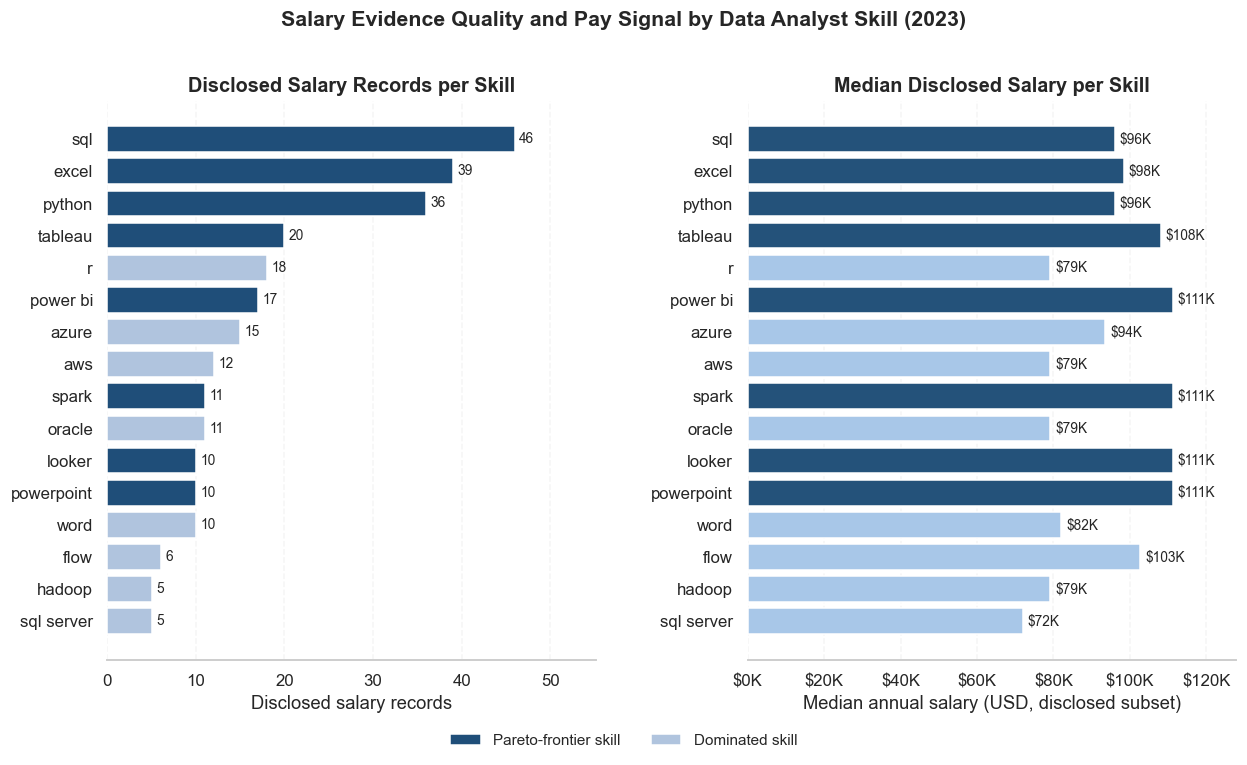

Skill,Prevalence,Salary Records,Median Salary (USD),Status
sql,51.6%,46,"$96,050",Pareto
excel,34.6%,39,"$98,500",Pareto
python,36.0%,36,"$96,050",Pareto
tableau,27.2%,20,"$108,088",Pareto
r,16.2%,18,"$79,200",Dominated
power bi,21.0%,17,"$111,175",Pareto
azure,8.4%,15,"$93,600",Dominated
aws,7.4%,12,"$79,200",Dominated
spark,5.6%,11,"$111,175",Pareto
oracle,5.4%,11,"$79,200",Dominated


In [7]:
# ------------------------------------------------------------------
# Evidence quality: salary record counts alongside median salary
# ------------------------------------------------------------------

evidence = (
    pareto_data
    .sort_values("salary_records", ascending=False)
    .copy()
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 6.5))

# --- Left: Salary records (evidence strength) ---
ax_n = axes[0]

colors_n = [
    "#1f4e79" if row["on_frontier"] else "#b0c4de"
    for _, row in evidence.iterrows()
]

bars_n = ax_n.barh(
    evidence.index,
    evidence["salary_records"],
    color=colors_n,
)

ax_n.bar_label(bars_n, labels=[str(int(v)) for v in evidence["salary_records"]],
               padding=3, fontsize=9)
ax_n.set(
    title="Disclosed Salary Records per Skill",
    xlabel="Disclosed salary records",
    ylabel="",
)
ax_n.set_xlim(0, evidence["salary_records"].max() * 1.20)
ax_n.grid(axis="x", linestyle="--", alpha=0.20)
ax_n.grid(axis="y", visible=False)
sns.despine(ax=ax_n, left=True, top=True, right=True)
ax_n.set_axisbelow(True)

# --- Right: Median salary ---
ax_s = axes[1]

colors_s = [
    "#24527a" if row["on_frontier"] else "#a8c7e8"
    for _, row in evidence.iterrows()
]

bars_s = ax_s.barh(
    evidence.index,
    evidence["median_salary"],
    color=colors_s,
)

ax_s.bar_label(
    bars_s,
    labels=[f"${v/1000:,.0f}K" for v in evidence["median_salary"]],
    padding=3,
    fontsize=9,
)
ax_s.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value / 1_000:,.0f}K"))
ax_s.set(
    title="Median Disclosed Salary per Skill",
    xlabel="Median annual salary (USD, disclosed subset)",
    ylabel="",
)
ax_s.set_xlim(0, evidence["median_salary"].max() * 1.15)
ax_s.grid(axis="x", linestyle="--", alpha=0.20)
ax_s.grid(axis="y", visible=False)
sns.despine(ax=ax_s, left=True, top=True, right=True)
ax_s.set_axisbelow(True)

ax_n.invert_yaxis()
ax_s.invert_yaxis()

# Shared legend
legend_elements = [
    Patch(facecolor="#1f4e79", label="Pareto-frontier skill"),
    Patch(facecolor="#b0c4de", label="Dominated skill"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.04),
)

plt.suptitle(
    "Salary Evidence Quality and Pay Signal by Data Analyst Skill (2023)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout(w_pad=3)
plt.savefig("figures/05_analyst_salary_evidence.png", dpi=150, bbox_inches="tight")
plt.show()
print()

# ------------------------------------------------------------------
# Evidence quality: summary table
# ------------------------------------------------------------------
evidence_table = (
    evidence.reset_index()
    .rename(columns={
        "job_skills": "Skill",
        "prevalence": "Prevalence",
        "salary_records": "Salary Records",
        "median_salary": "Median Salary (USD)",
        "on_frontier": "Status",
    })
)

# Status labels
evidence_table["Status"] = evidence_table["Status"].map({
    True: "Pareto",
    False: "Dominated",
})

evidence_table = evidence_table[
    [
        "Skill",
        "Prevalence",
        "Salary Records",
        "Median Salary (USD)",
        "Status",
    ]
]

display(
    evidence_table.style
    .format({
        "Prevalence": "{:.1%}",
        "Salary Records": "{:.0f}",
        "Median Salary (USD)": "${:,.0f}",
    })
    .hide(axis="index")
)


SQL commands the largest salary evidence base among analyst skills, providing the most
reliable pay-signal estimate. Tableau and Excel also have relatively strong evidence
bases. Python's salary records within the analyst subset are meaningful but fewer,
reflecting that fewer analyst postings disclose salary when Python is listed.

Power BI's median disclosed salary sits above SQL and Excel in the evidence-qualified
sample, but its record count is lower. The difference in median salary should therefore
be read directionally rather than as a precise market benchmark.

Skills at the lower end of the record count (five to ten records) are included for
completeness but carry the greatest uncertainty. These estimates should therefore be interpreted cautiously until supported by larger salary samples.


## Implications

- **SQL is the optimal entry point.** Highest reach, strongest salary evidence, and
  no skill dominates it on both dimensions. For candidates building their first
  analyst position or maximising optionality, SQL is the non-negotiable foundation.

- **Power BI and Tableau expand the frontier upward.** Both skills are associated with
  a higher median disclosed salary in the analyst subset. Adding either after SQL
  creates a connected BI workflow that is among the most commonly requested analyst
  combinations.

- **Python extends reach beyond pure analysis.** Python's prevalence in analyst postings
  suggests that many employers are hiring for roles that blur the boundary with data
  engineering and data science. Adding Python increases cross-role mobility at the cost
  of a narrower pure-analyst opportunity set.

- **Evidence quality conditions every salary claim.** No analyst skill has salary
  coverage sufficient to treat its median as a market benchmark. Every pay-signal
  comparison should be accompanied by a record count; conclusions based on fewer
  than ten records require independent validation.

- **No single skill is universally optimal.** The Pareto frontier exists precisely
  because reach and pay signal cannot always be maximised simultaneously. Prioritisation
  depends on whether the candidate's goal is maximum market access, access to
  better-compensated sub-roles, or cross-role mobility.


## Limitations

- Salary is missing for 98.5% of India Data Analyst postings. The disclosed subset
  may be systematically different from the full market.
- Skill-level salary medians within the analyst role reflect the overlap of postings
  that mention a skill AND disclose salary. Both selection effects operate simultaneously.
- Annual USD standardisation may not reflect local Indian compensation structures.
- The analysis does not control for seniority, employer size, or location within the
  analyst role.
- The Pareto frontier depends on the selected prevalence and salary-record thresholds. Small threshold changes may alter which skills appear on the frontier.
- This notebook covers 2023 data; it does not establish current market conditions.
